# Midsommerso Dolerites ca. 1382 Ma paleomagnetic pole

## Geologic context

The Midsommerso Dolerites are mafic sills and dykes intruding the Mesoproterozoic
sedimentary succession and the Zig-Zag Dal Basalt of eastern North Greenland
(Marcussen & Abrahamsen, 1983). U-Pb baddeleyite dating gives 1382 ± 2 Ma (Upton
et al., 2005). The remanence is a single-polarity, magnetite-carried
magnetization.

## Pole

This notebook recreates the Midsommerso Dolerites pole at the site level from the
10 sites of Marcussen & Abrahamsen (1983).

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Site means are loaded from `../data/1382_Midsommerso_Dolerites/` (the bedding-
corrected directions of Marcussen & Abrahamsen, 1983).

In [2]:
sites_geo, sites_tc = pt.load_magic_sites('../data/1382_Midsommerso_Dolerites/sites.txt')
sub = sites_tc if len(sites_tc) else sites_geo
study_lat, study_lon = 81.6, 333.4
print(f'{len(sub)} sites (bedding-corrected)')
sub[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_alpha95', 'dir_k', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

10 sites (bedding-corrected)


,site,lat,lon,dir_dec,dir_inc,dir_alpha95,dir_k,dir_n_samples,vgp_lat,vgp_lon
0,DL-01,81.8,327.8,75.5,-14.4,5.6,74,10,-10.0,69.2
1,DL-02,81.8,327.8,83.2,-10.4,3.6,183,10,-10.0,61.3
2,DL-03,81.8,327.8,80.1,-9.1,8.2,55,7,-7.0,64.3
3,DL-04,81.8,327.8,79.0,-8.6,3.5,220,9,-9.0,65.3
4,DL-06,81.8,327.8,82.9,-12.1,3.3,240,9,-9.0,61.7
5,DL-08,81.8,327.8,101.4,-35.5,3.0,251,10,-10.0,53.5
6,DL-09,81.8,327.8,101.8,-28.6,1.8,662,10,-10.0,52.3
7,DL-10,81.8,327.8,84.4,-12.5,4.1,114,12,-12.0,65.6
8,DL-11,81.8,327.8,90.9,-10.3,4.8,81,12,-12.0,59.0
9,DL-12,81.8,327.8,81.5,-2.6,5.6,68,11,-11.0,67.7


Plon: 242.0  Plat: 10.0
Number of directions in mean (n): 10
Angular radius of 95% confidence (A_95): 3.5
Precision parameter (k) estimate: 197.0

prior compilation (GPMDB 99): 10.0 N / 242.0 E, N=10


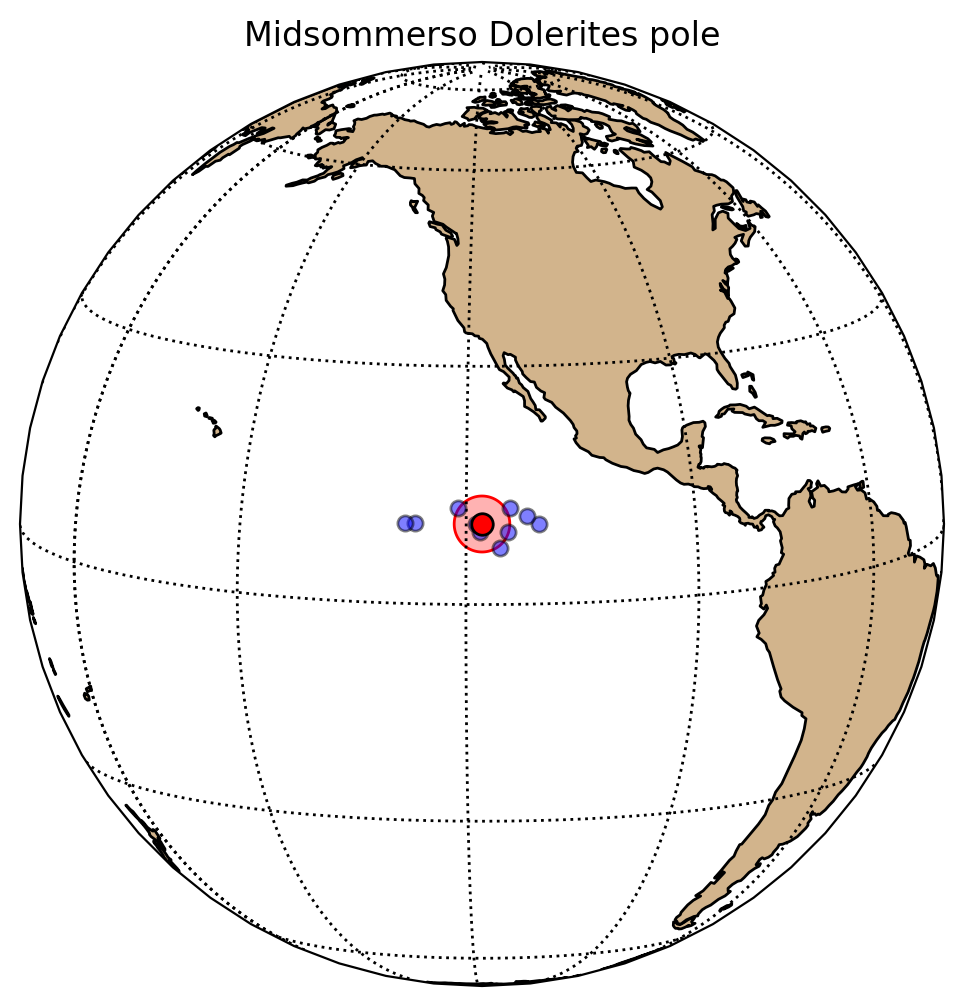

In [3]:
# the VGPs are southern in the student convention; report at the positive-latitude
# antipode to match the prior compilation (GPMDB 99)
vgp_block, pm = pt.compute_mean_pole(sub, unify_polarity=True)
if pm['inc'] < 0:
    vgp_block, pm = pt.compute_mean_pole(sub, unify_polarity=True, flip=True)
pole_mean = pm
ipmag.print_pole_mean(pole_mean)
print('\nprior compilation (GPMDB 99): 10.0 N / 242.0 E, N=10')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Midsommerso Dolerites pole')
plt.show()

Dec: 265.6  Inc: 14.5
Number of directions in mean (n): 10
Angular radius of 95% confidence (a_95): 7.9
Precision parameter (k) estimate: 38.8


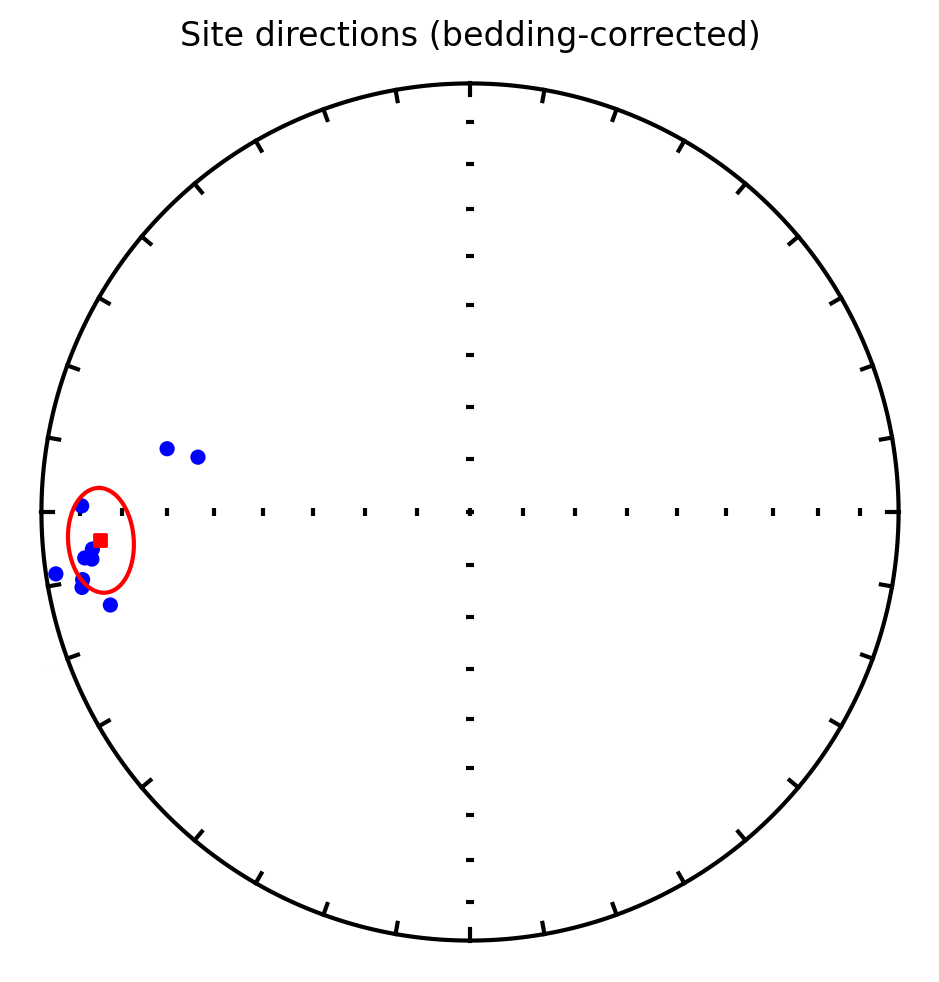

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(sub, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
plt.title('Site directions (bedding-corrected)')
plt.show()

## Paleosecular variation

The VGPs are over-concentrated (K > 70), so the Deenen et al. (2011) test flags
under-sampling of paleosecular variation — consistent with the prior compilation
scoring R2 = 0.

A_95 of 3.5 is too small for Deenen criteria of 4.8 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

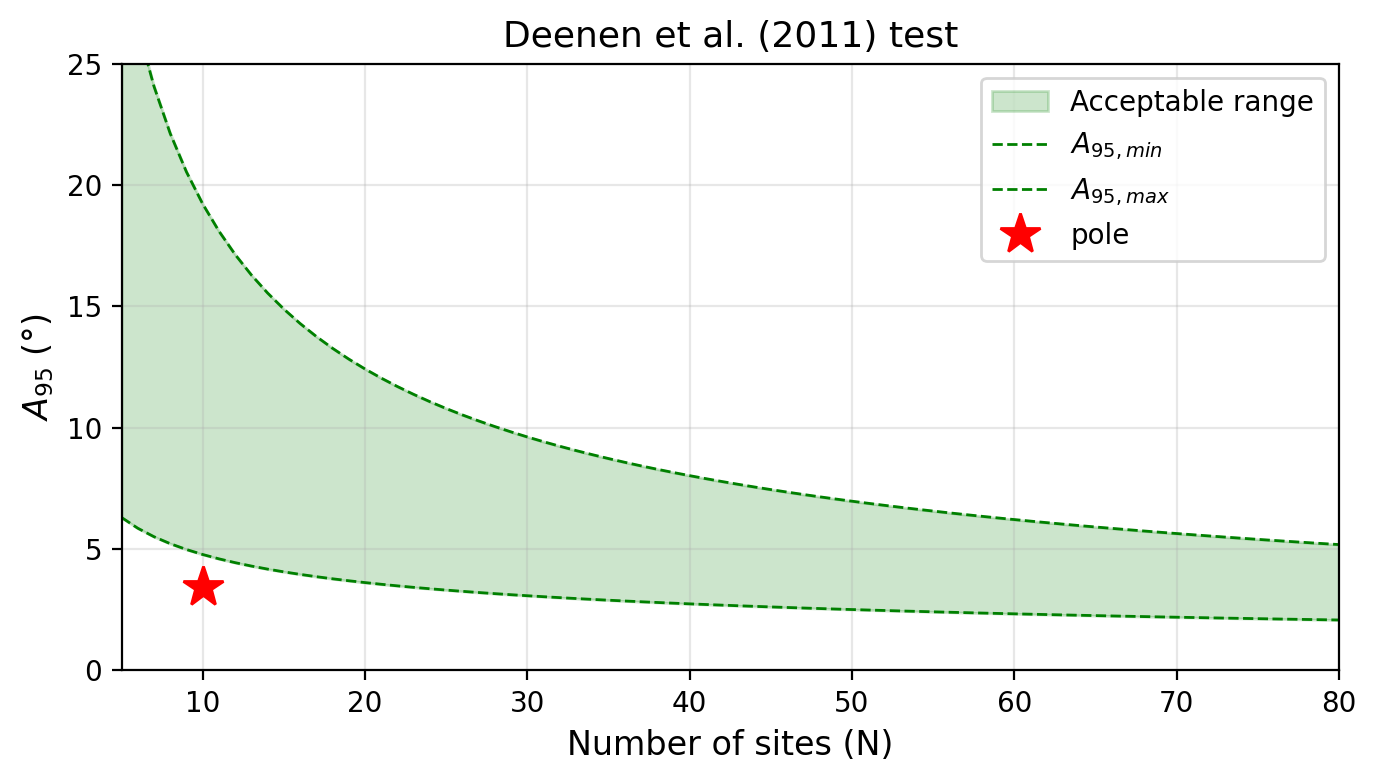

In [5]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

posx and posy should be finite values
posx and posy should be finite values


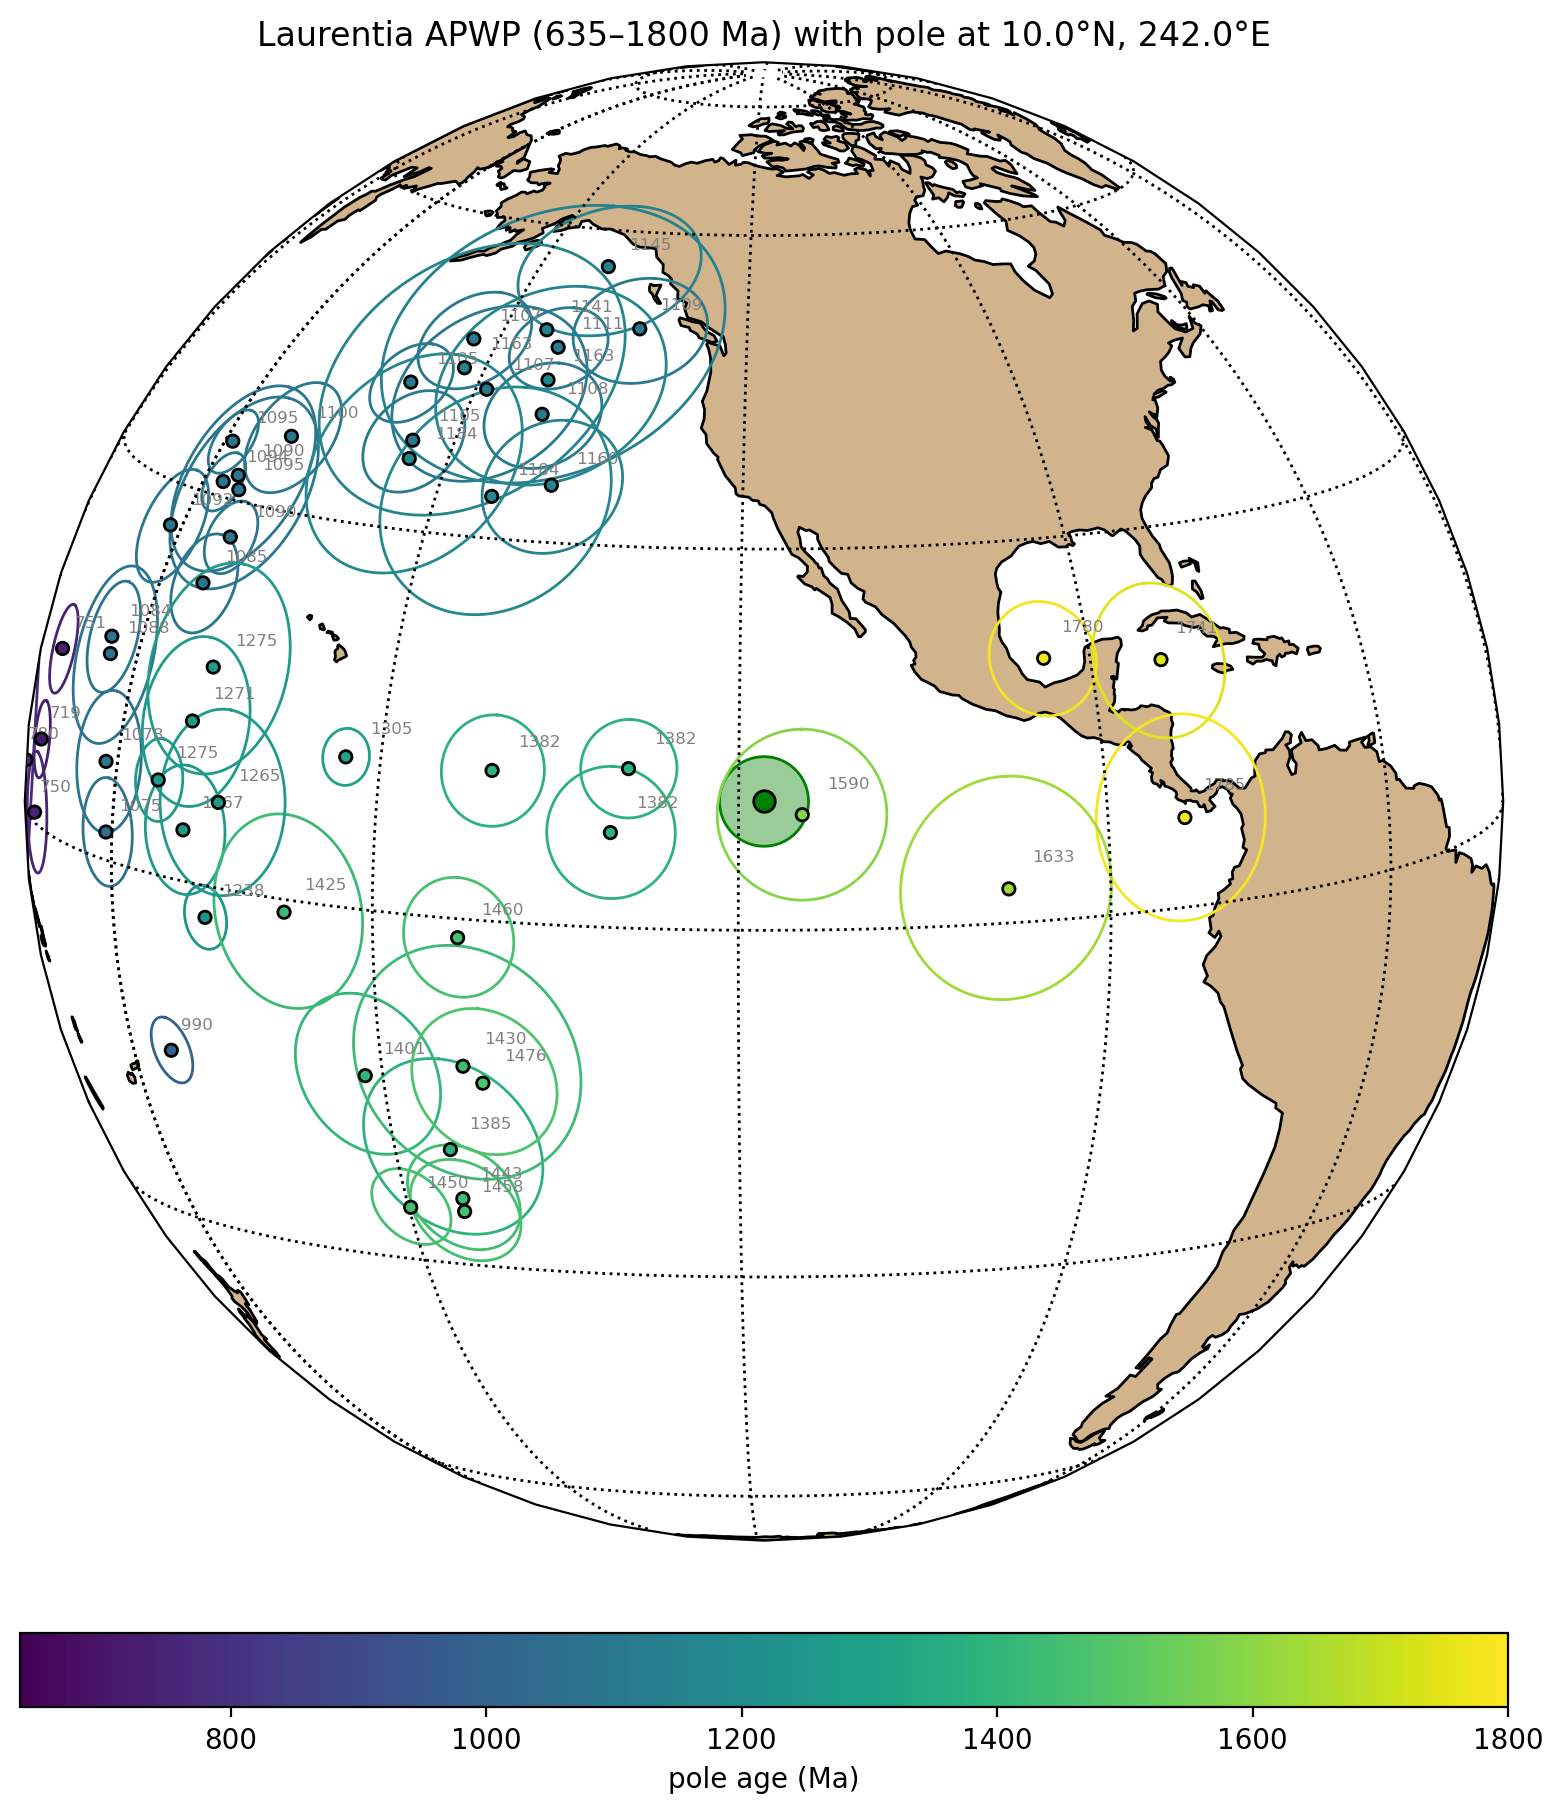

In [6]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

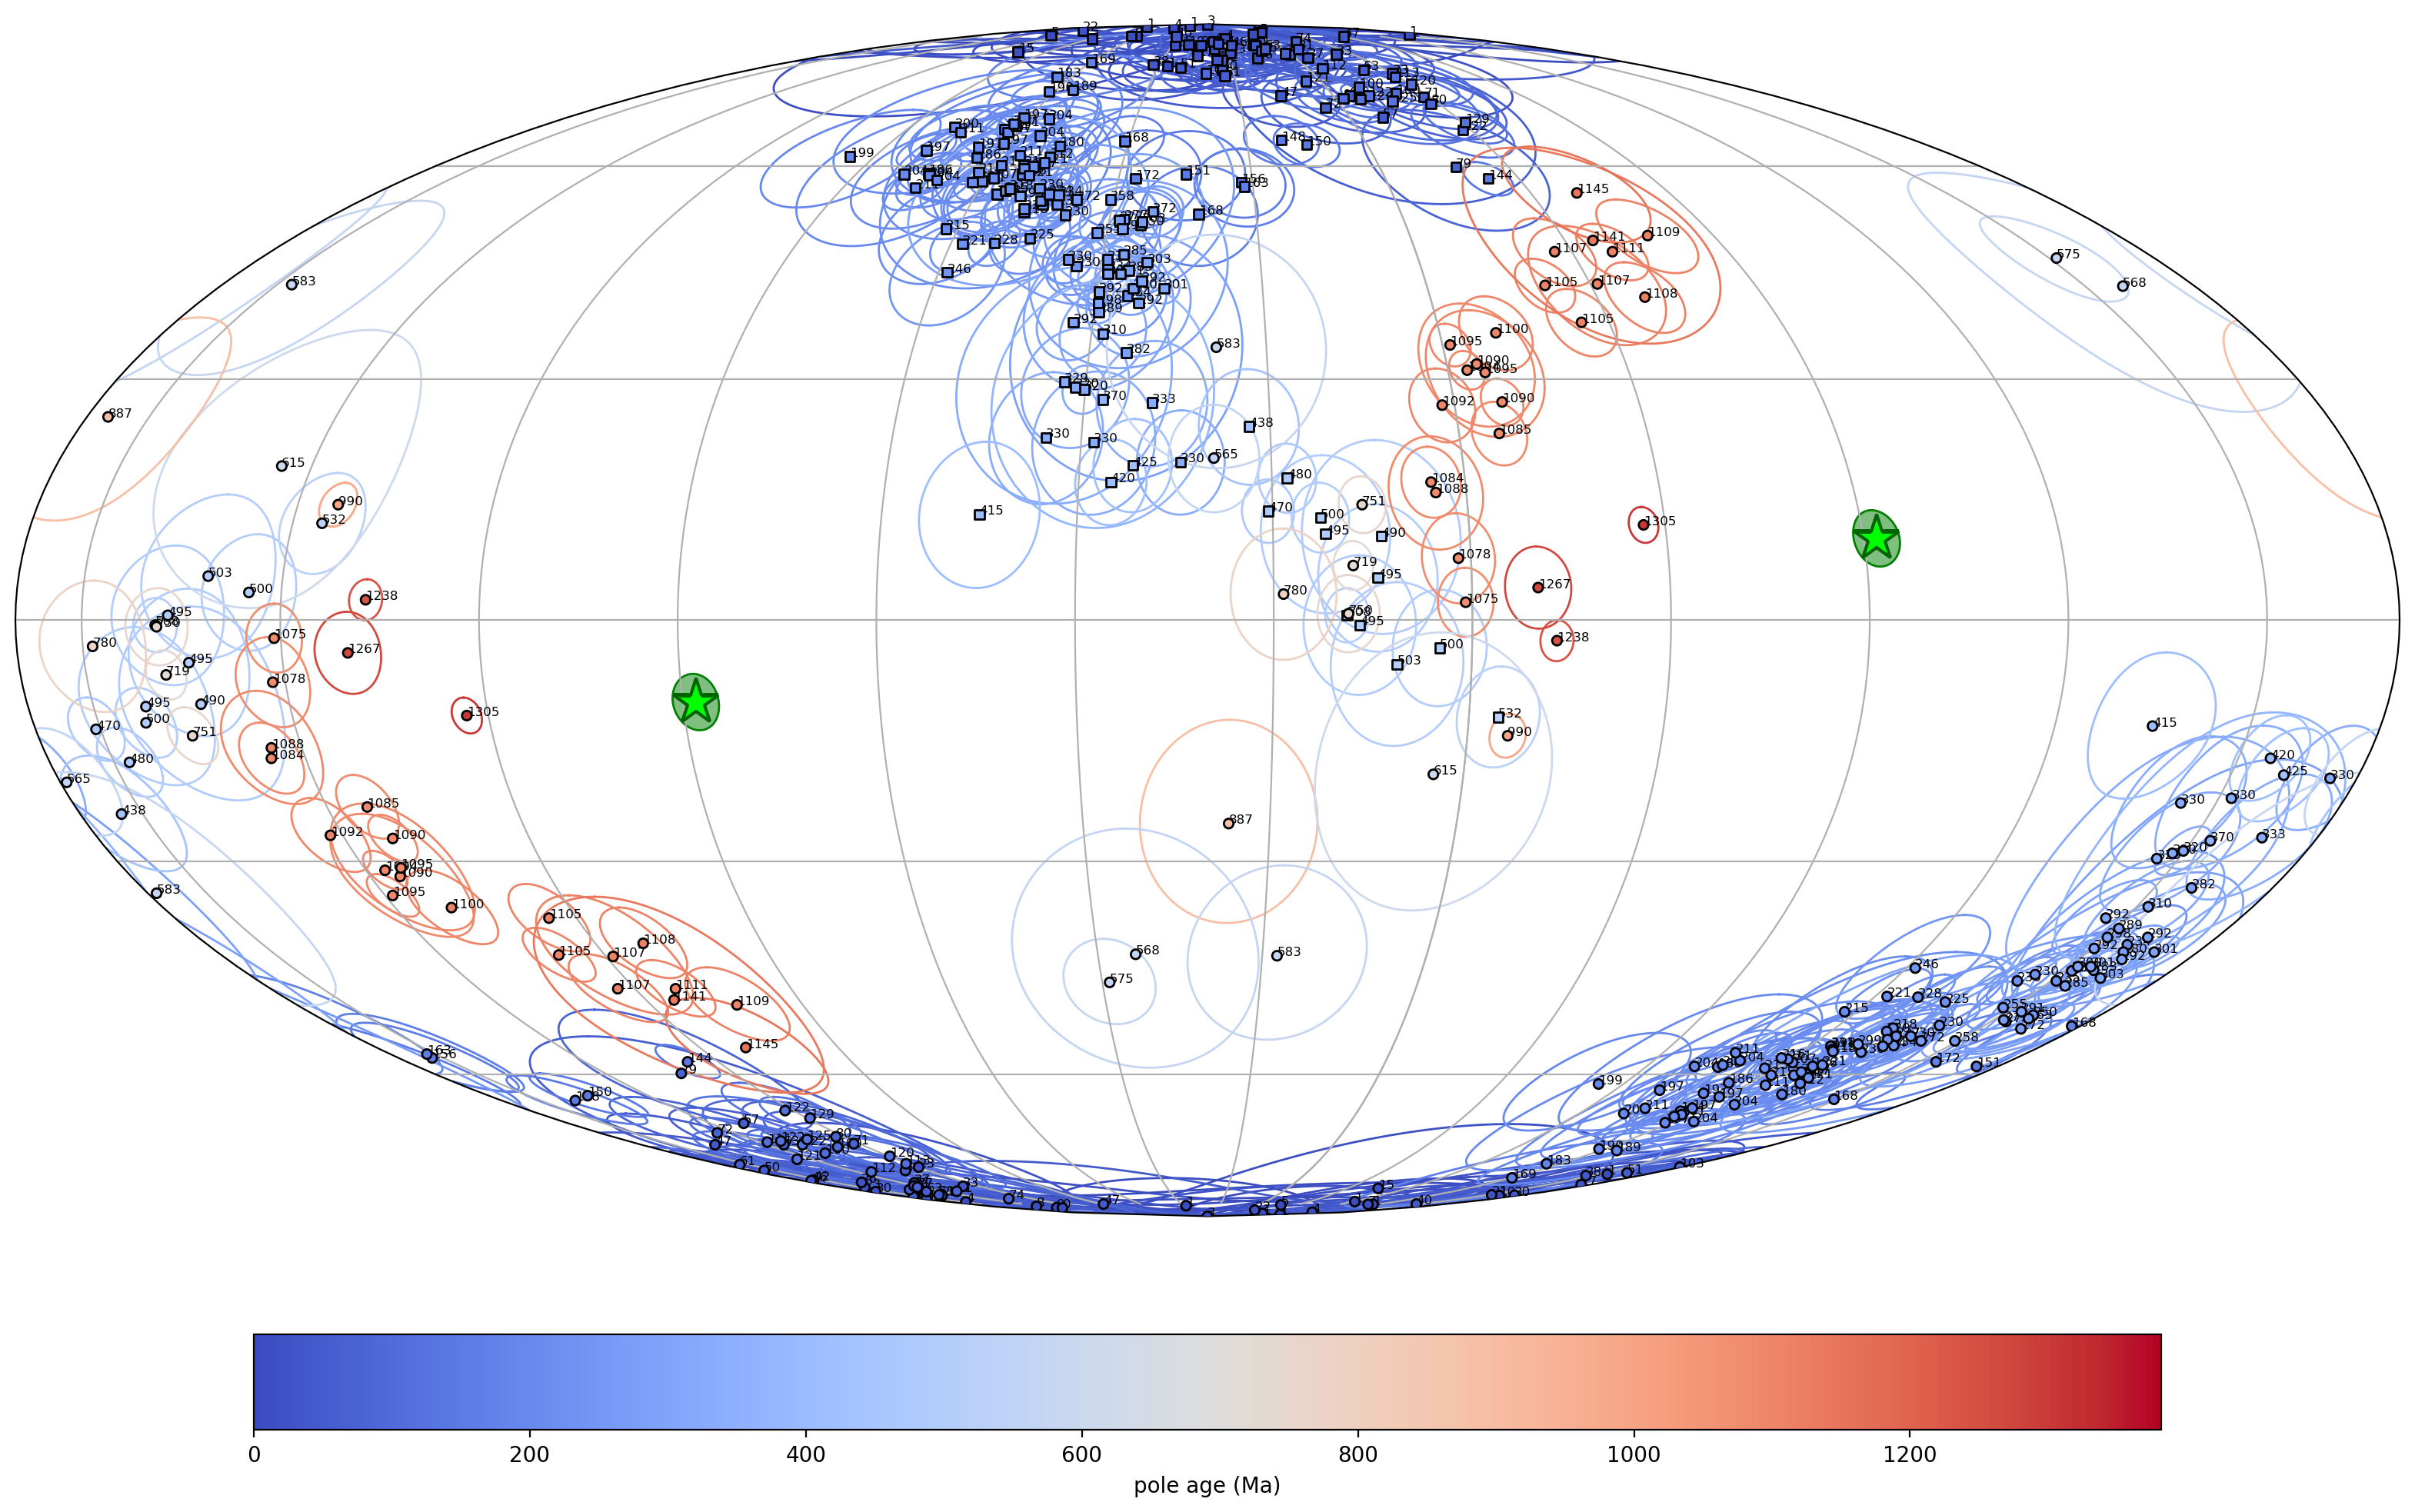

<GeoAxesSubplot:>

In [7]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Midsommerso Dolerites', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1382)

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

{'Mode': 'Mode 1',
 'Dec': 242.00786200198354,
 'Inc': 10.042620466560416,
 'N': 10,
 'Mu': 1.082413194666288,
 'Mu_critical': 1.207,
 'Me': 0.6244555721465529,
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

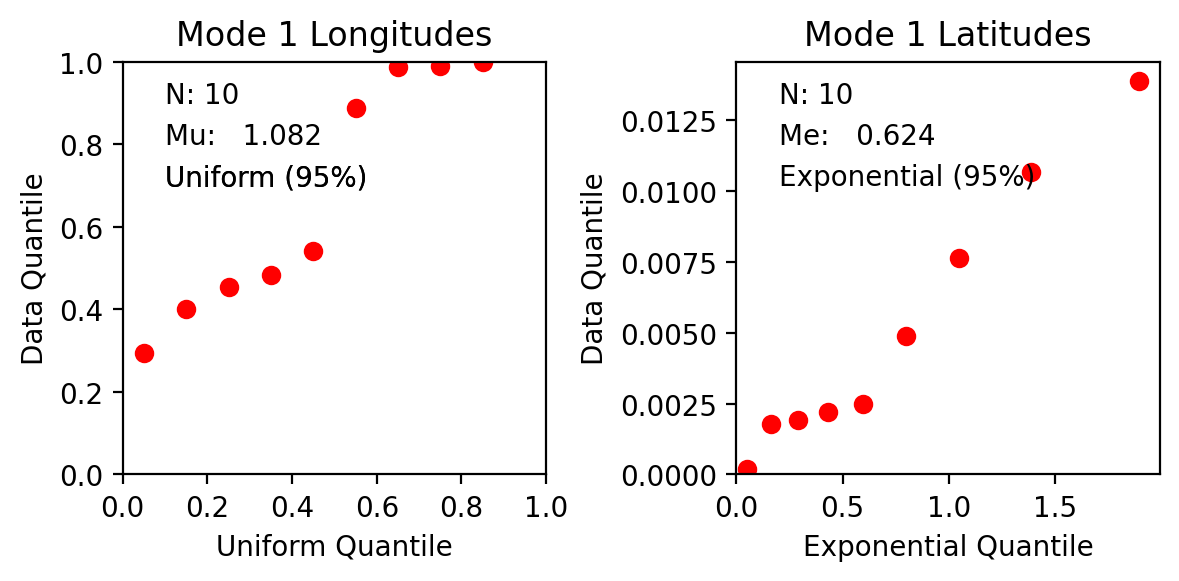

In [8]:
fishqq_result = pt.fishqq_vgps(sub, unify_polarity=True)
fishqq_result

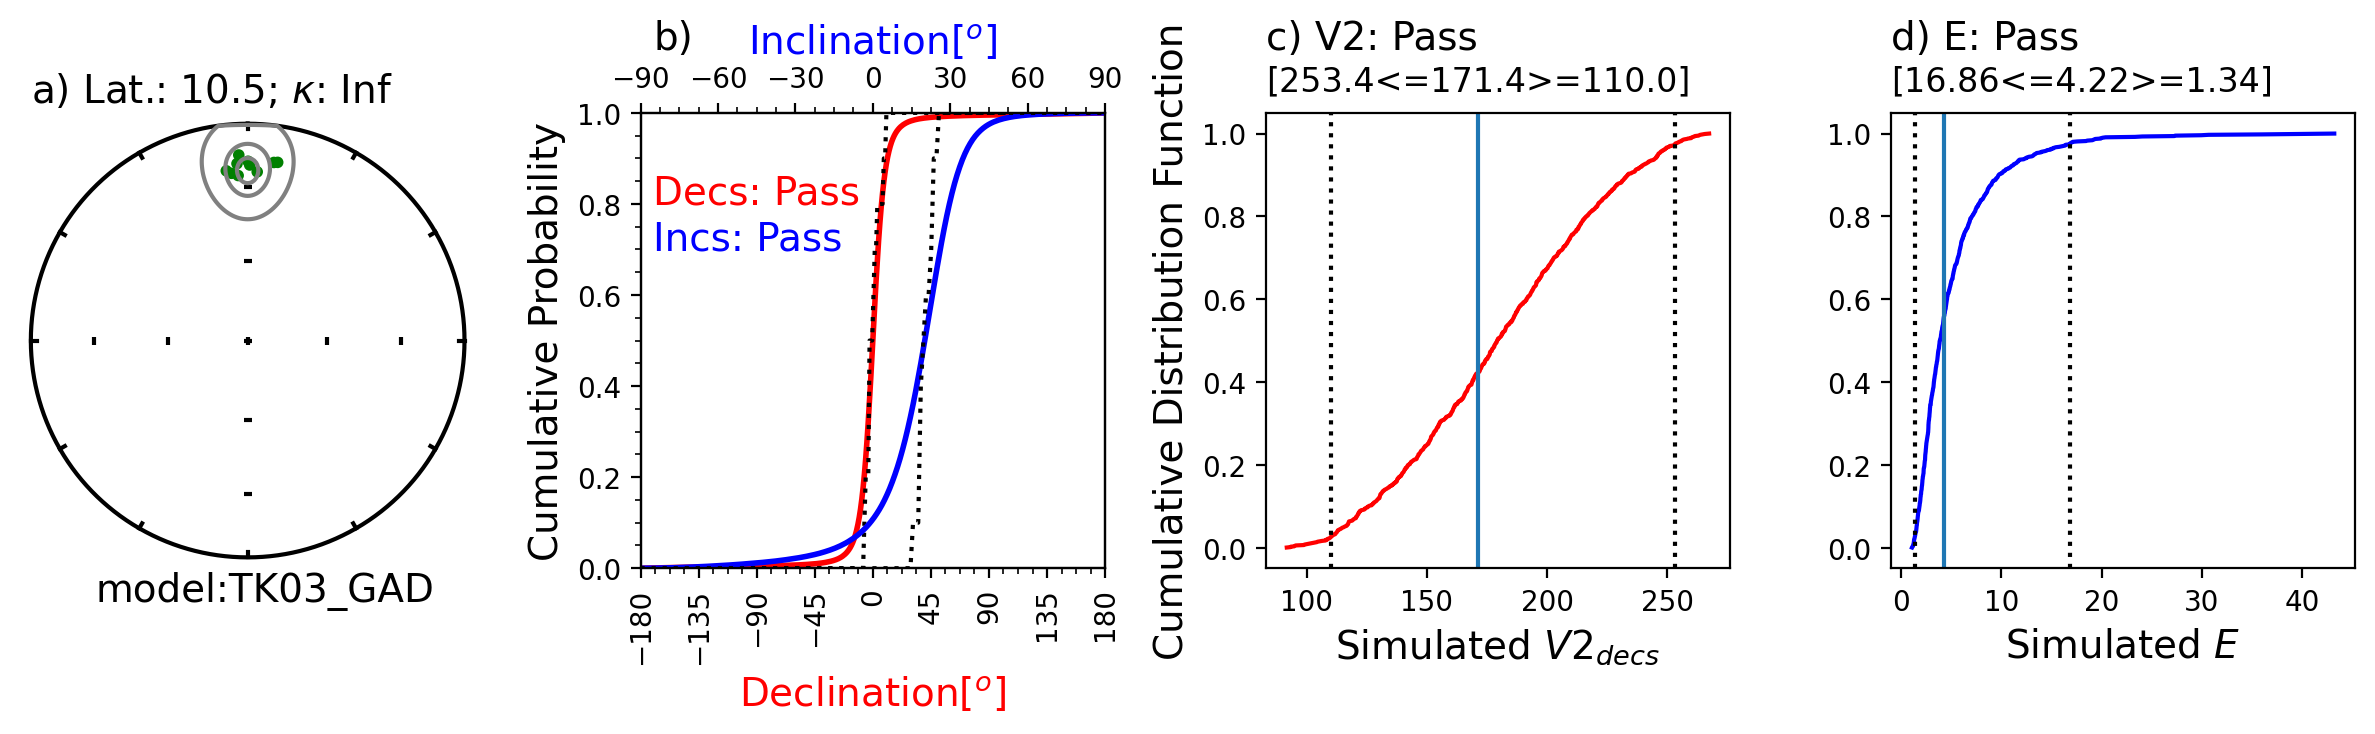

paleolatitude = 10.5 deg; elongation E = 4.22 (consistent with TK03.GAD)


In [9]:
_slat, _slon = float(sub['lat'].mean()), float(sub['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(sub, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(sub, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb baddeleyite 1382 ± 2 Ma on the intrusive Midsommerso Dolerites (Upton et al., 2005). |
| 2 | Techniques and statistical analysis | **0** | AF demagnetization; the VGPs are over-concentrated (K > 70, A95 below the Deenen et al. (2011) lower bound), indicating under-averaged paleosecular variation. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence (Marcussen & Abrahamsen, 1983). |
| 4 | Field tests constrain age of magnetization | **0** | No baked-contact or fold test. |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous eastern North Greenland (Laurentia-Greenland); bedding-corrected. |
| 6 | Presence of reversals | **0** | Single polarity. |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **4/7** | Grade B |

### Midsommerso Dolerites pole

| | This study (site VGPs) | Marcussen & Abrahamsen (1983) | Previous Nordic compilation |
|---|---|---|---|
| Component | Characteristic remanence (magnetite) | Stable remanence (dolerites) | — |
| N (sites) | 10 | 10 | 10 |
| N (specimens) | 100 | 100 | 100 |
| Dec (°) | 265.6 | 85.6 | 85.6 |
| Inc (°) | 14.5 | −14.5 | −14.5 |
| k (direction) | 38.8 | 39 | 39.0 |
| α95 (direction, °) | 7.9 | 7.0 | 7.8 |
| Pole lat (°N) | 10.0 | −6.9 | 6.9 |
| Pole lon (°E) | 242.0 | 62.0 | 242.0 |
| A95, pole (°) | 3.5 | 5.1 | 5.1 |
| dp / dm (°) | — | — | 5.1 / 5.1 |


In [10]:
summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='Midsommerso Dolerites',
    sites=sub,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization (magnetite); single polarity',
    tests='',
    gpmdb_number='99',
    percent_reversed=0,
    demag_code=3,
    R1=1, R2=0, R3=1, R4='', R5=1, R6=0, R7=1, Grade='B',
    nominal_age=1382, lomagage=1380, himagage=1384,
    REF_method='U-Pb baddeleyite age 1382 +/- 2 Ma on the intrusive Midsommerso Dolerites (Upton et al., 2005); the Zig-Zag Dal Basalts are correlated.',
    POLE_AUTHORS='Marcussen, C., & Abrahamsen, N.',
    YEAR=1983,
    JOURNAL='Geophysical Journal of the Royal Astronomical Society',
    VOLUME='73',
    VPAGES='',
    TITLE='Palaeomagnetism of the Proterozoic Zig-Zag Dal Basalt and the Midsommerso Dolerites, eastern North Greenland',
    COMMENT='Midsommerso Dolerites pole recreated at the site level from Marcussen & Abrahamsen (1983) (audited contribution: dir_tilt_correction set to 100 = bedding-corrected; corrupted Upton 2005 DOI fixed to ...0634-7). Reported at the positive-latitude antipode to match the prior compilation (GPMDB 99; the student computed the southern antipode). Single polarity, over-concentrated VGPs (K>70) -> R2=0; no field test; U-Pb 1382+/-2 Ma -> R1=1. R=4, Grade B.'
)
pt.save_nordic_summary(summary, '1382_Midsommerso_Dolerites')
summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,Midsommerso Dolerites,GPMDB:99,Characteristic remanent magnetization (magneti...,,100,81.6,333.4,10,100,...,1384,U-Pb baddeleyite age 1382 +/- 2 Ma on the intr...,Midsommerso Dolerites,"Marcussen, C., & Abrahamsen, N.",1983,Geophysical Journal of the Royal Astronomical ...,73,,Palaeomagnetism of the Proterozoic Zig-Zag Dal...,Midsommerso Dolerites pole recreated at the si...
